<a href="https://colab.research.google.com/github/Smarth2005/UCS761-Deep-Learning/blob/main/notebooks/Lab-7%20Time%20Series%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Lab Exercise-7
### Forecast electrical consumption for the next 10 years using RNN, LSTM, GRU & Vision transformer.

Dataset Link: https://www.kaggle.com/datasets/kandij/electric-production


### Setup and Dataset Loading

In [35]:
# Imports
import os
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
from pylab import rcParams
rcParams['figure.figsize'] = 10, 7

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Input
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Dropout, GlobalAveragePooling1D

In [4]:
# Set random seeds for reproducibility
np.random.seed(42)

In [5]:
path = kagglehub.dataset_download("kandij/electric-production")
# Find the CSV file
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            file_path = os.path.join(root, file)

100%|██████████| 2.63k/2.63k [00:00<00:00, 6.08MB/s]

Extracting files...


In [6]:
# Load data
df = pd.read_csv(file_path)
# Rename columns for easier access (Standard: Date, Value)
df.columns = ['Date', 'Production']
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df.head()

,Production
Date,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


### Visualizing the time series

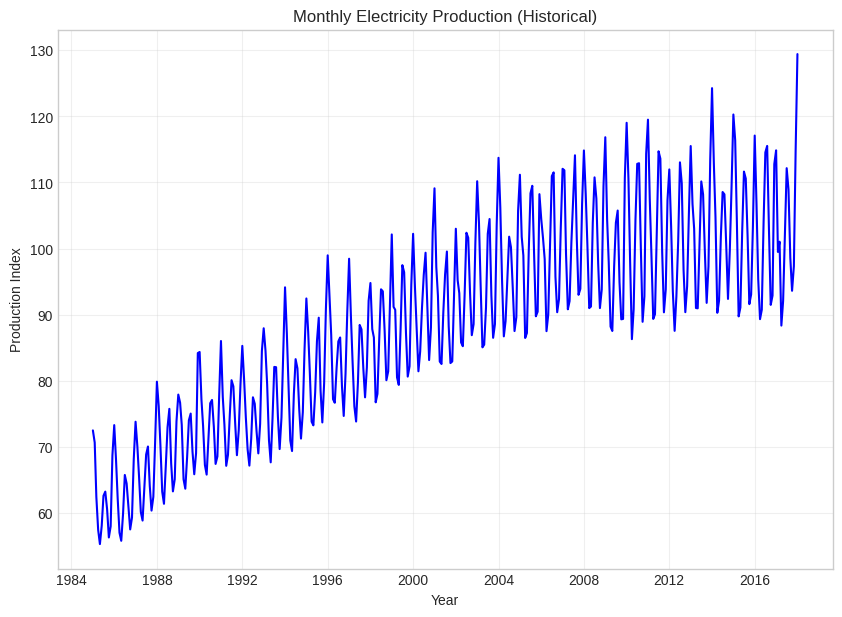

In [7]:
plt.plot(df['Production'], color='blue', linewidth=1.5)
plt.title('Monthly Electricity Production (Historical)')
plt.xlabel('Year')
plt.ylabel('Production Index')
plt.grid(True, alpha=0.3)
plt.show()

For time series forecasting, a series needs to be stationary. The series should have a constant mean, variance, and covariance.

The initial visualization reveals a prominent upward trend and a consistent seasonal pattern, indicating that the mean of the series is not constant. Hence, we have identified that our series is not stationary. We need to have a stationary series to do time series forecasting. In the next stage, we will try to convert this into a stationary series.

<Axes: ylabel='Density'>

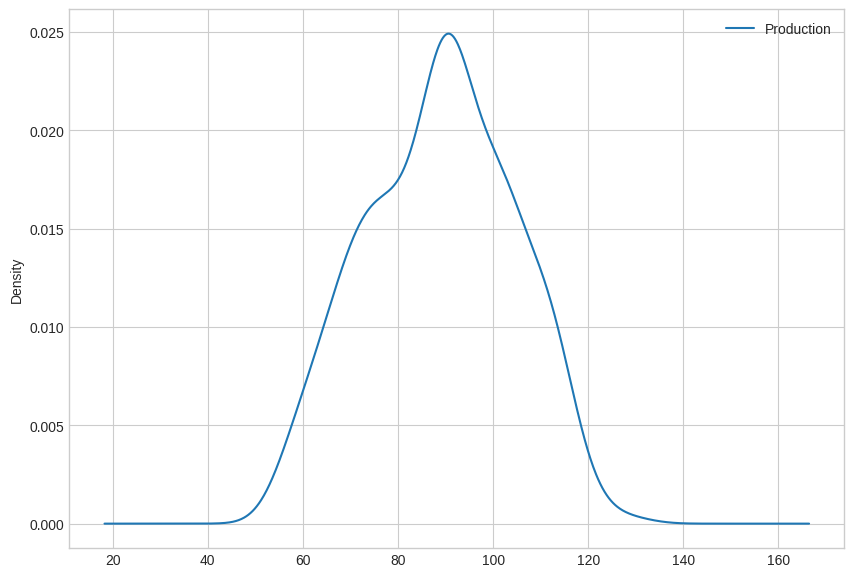

In [8]:
df.plot(kind='kde',linewidth=1.5)

We can observe a near-normal distribution (bell-curve) over consumption values.

In order to perform a time series analysis, we may need to separate seasonality and trend from our series. The resultant series will become stationary through this process.

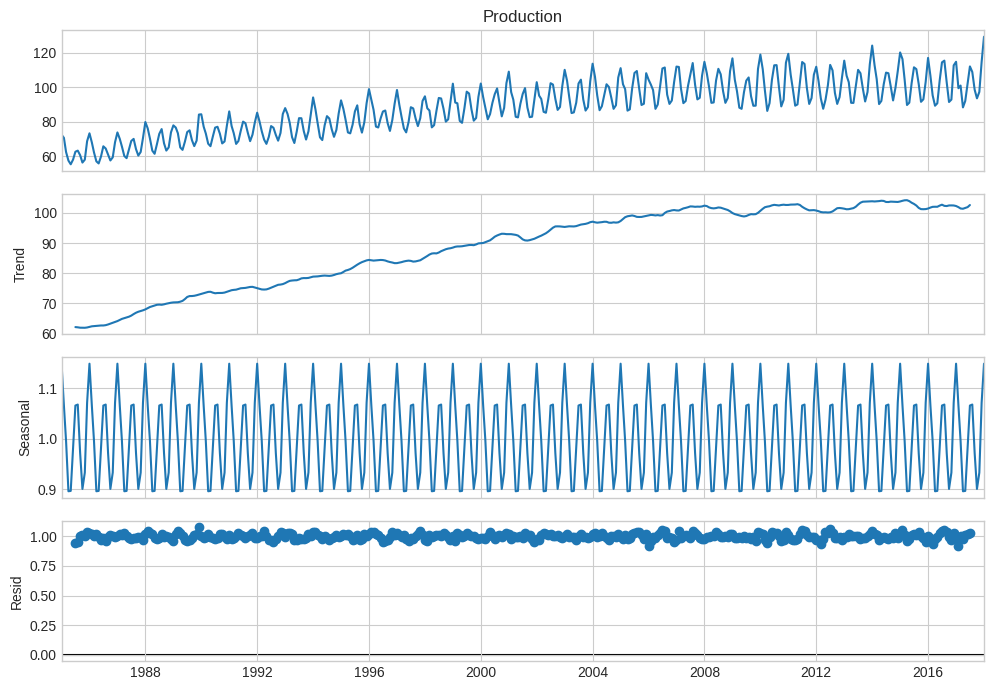

In [9]:
# Seasonal Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# We use period=12 because it is monthly data (12 months = 1 cycle)
decomposition = seasonal_decompose(df['Production'], model='multiplicative', period=12)

fig = decomposition.plot()
# fig.set_size_inches(12, 8)

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(1.5)

plt.show()

This gives us more insight into our data and real-world actions. Clearly, there is an upward trend and a recurring event where electricity consumption shoots maximum every year.

/tmp/ipykernel_11327/719066893.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='Production', data=df_eda, palette='viridis')


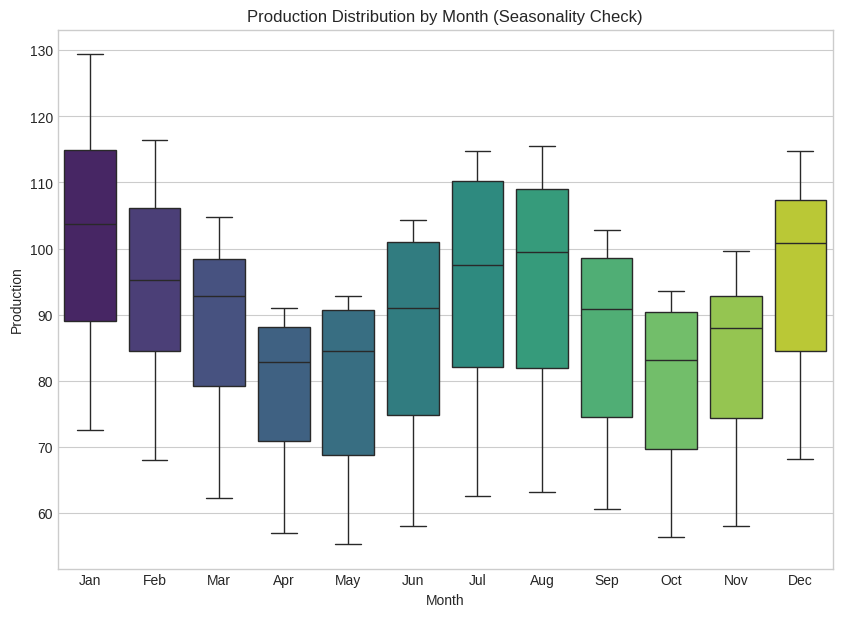

In [10]:
# Seasonality Analysis
# Create features for Month and Year
df_eda = df.copy()
df_eda['Month'] = df_eda.index.month
df_eda['Year'] = df_eda.index.year

sns.boxplot(x='Month', y='Production', data=df_eda, palette='viridis')
plt.title('Production Distribution by Month (Seasonality Check)')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

### Stationary Check (Rolling statistics)

To check if a series is stationary or not, we perform ADF (Augmented Dickey-Fuller) Test. It can be used to determine the presence of unit root in the series, and hence help us understand if the series is stationary or not. The null and alternate hypothesis of this test is:

Null Hypothesis ($H_0$): The series has a unit root (it is non-stationary).

Alternative Hypothesis ($H_1$): The series does not have a unit root (it is stationary).

Note: If both mean and standard deviation are flat lines (constant mean and constant variance), the series becomes stationary.

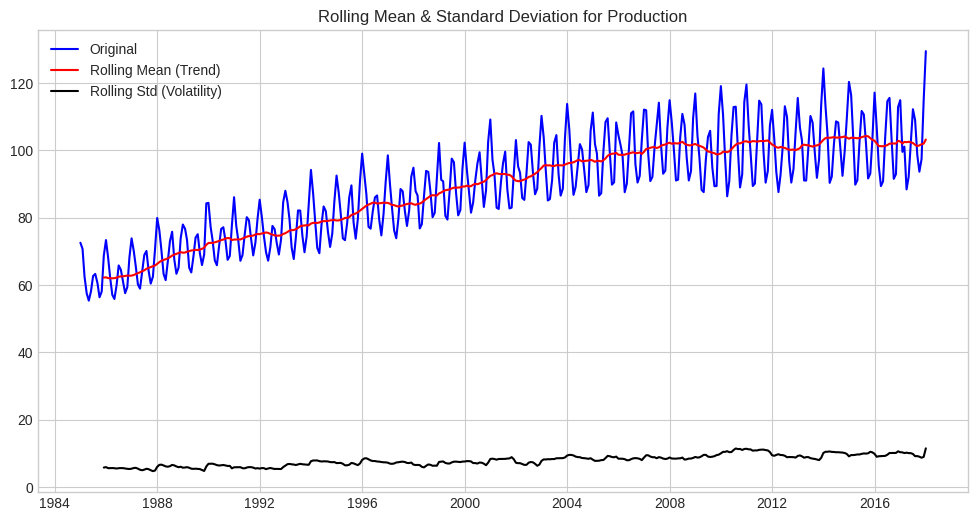

Results of dickey fuller test for Production
Test Statistics                 -2.256990
p-value                          0.186215
No. of lags used                15.000000
Number of observations used    381.000000
critical value (1%)             -3.447631
critical value (5%)             -2.869156
critical value (10%)            -2.570827
dtype: float64


In [11]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries, column_name='Production'):
    # Calculate rolling mean and standard deviation using the input data, not 'df'
    rolling_mean = timeseries[column_name].rolling(window=12).mean()
    rolling_std = timeseries[column_name].rolling(window=12).std()

    plt.figure(figsize=(12, 6))
    plt.plot(timeseries[column_name], color='blue', label='Original', linewidth=1.5)
    plt.plot(rolling_mean, color='red', label='Rolling Mean (Trend)', linewidth=1.5)
    plt.plot(rolling_std, color='black', label='Rolling Std (Volatility)', linewidth=1.5)
    plt.legend()
    plt.title(f'Rolling Mean & Standard Deviation for {column_name}')
    plt.show()

    # Perform dickey fuller test
    print(f"Results of dickey fuller test for {column_name}")
    adft = adfuller(timeseries[column_name].dropna(), autolag='AIC')
    output = pd.Series(adft[0:4], index=['Test Statistics','p-value','No. of lags used','Number of observations used'])
    for key, values in adft[4].items():
        output['critical value (%s)' % key] = values
    print(output)

test_stationarity(df, 'Production')

<div align="justify">

Through the above graph, we can see the increasing mean and standard deviation and hence our series is not stationary.

We see that the p-value is greater than 0.05 so we cannot reject the Null hypothesis. Also, the test statistics is greater than the critical values. so the data is non-stationary.

To get a stationary series, we need to eliminate the trend and seasonality from the series.


</div>

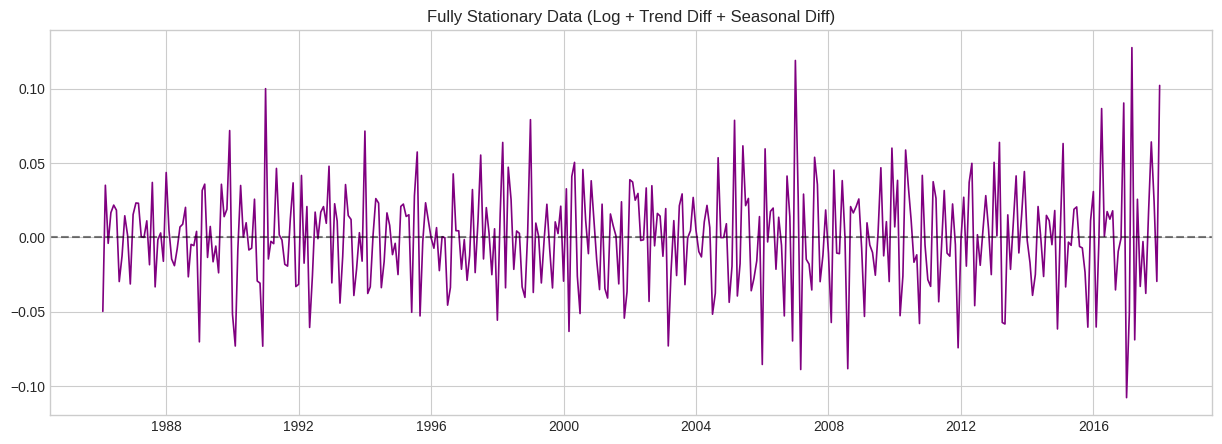

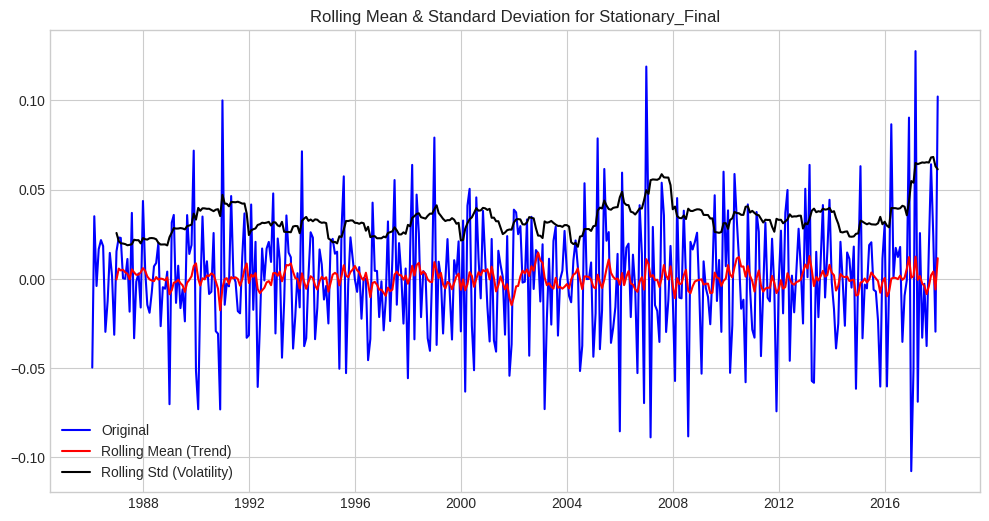

Results of dickey fuller test for Stationary_Final
Test Statistics               -8.053167e+00
p-value                        1.720234e-12
No. of lags used               1.500000e+01
Number of observations used    3.680000e+02
critical value (1%)           -3.448245e+00
critical value (5%)           -2.869426e+00
critical value (10%)          -2.570971e+00
dtype: float64


In [12]:
# 1. Log Transformation (Stabilize Variance)
df['Log_Production'] = np.log(df['Production'])

# 2. First-Order Differencing (Remove Trend)
df['Log_Diff'] = df['Log_Production'].diff()

# 3. Seasonal Differencing (Remove Seasonality)
# We subtract the value from 12 months ago from the already differenced data
df['Stationary_Final'] = df['Log_Diff'].diff(12)

# 4. Drop NaNs
# First-order diff creates 1 NaN, Seasonal diff creates 12 more.
df_clean = df.dropna()

# 5. Visualization
plt.figure(figsize=(15, 5))
plt.plot(df_clean['Stationary_Final'], color='purple', linewidth=1.2)
plt.title('Fully Stationary Data (Log + Trend Diff + Seasonal Diff)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

# 6. Verify with ADF Test
test_stationarity(df_clean, 'Stationary_Final')

### Autocorrelation (Determining "Look-back" Window)

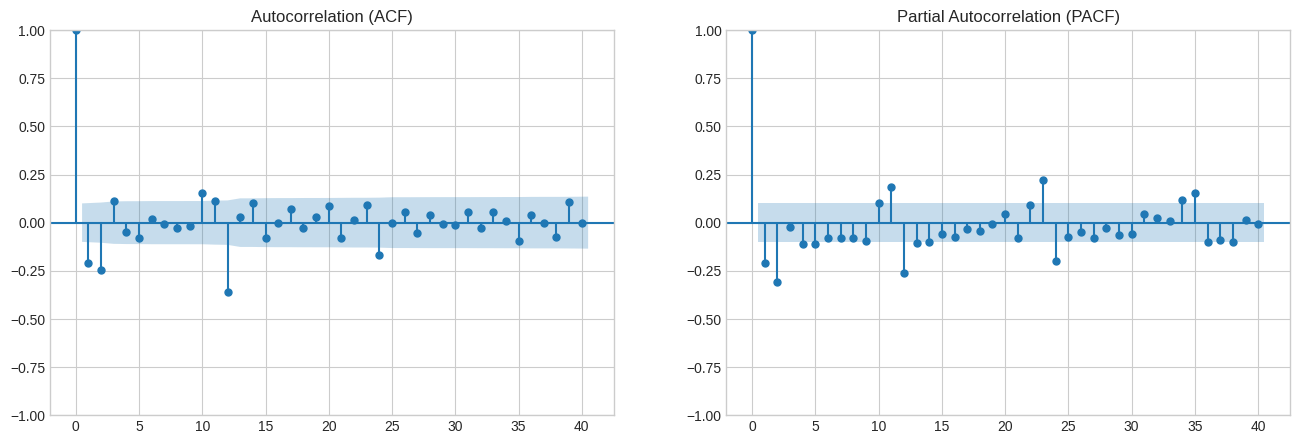

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# We check the ACF/PACF on the stationary data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# ACF: Shows the "Memory" of the data
plot_acf(df_clean['Stationary_Final'], lags=40, ax=ax1)
ax1.set_title('Autocorrelation (ACF)')

# PACF: Shows the direct relationship of lags
plot_pacf(df_clean['Stationary_Final'], lags=40, ax=ax2)
ax2.set_title('Partial Autocorrelation (PACF)')

plt.show()

The rapid decay of autocorrelation towards zero confirms that the series has achieved stationarity. Notably, a significant negative spike at Lag 12 persists in both plots. This indicates that while the global seasonal trend was removed, a strong seasonal dependency remains.

This mathematically justifies the selection of a 12-month look-back window for our RNN, LSTM, GRU, and Vision Transformer models, ensuring they have sufficient temporal context to capture these annual residuals.

### Scaling and Windowing

In [14]:
from sklearn.preprocessing import MinMaxScaler

# Scaling the stationary data
scaler = MinMaxScaler(feature_range=(0, 1))
# Use the 'Stationary_Final' column we created in the last step
scaled_data = scaler.fit_transform(df_clean[['Stationary_Final']])

# Function to create sliding windows
def create_sequences(data, window_size=12):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : (i + window_size)])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

# We use 12 months to capture the annual cycle
WINDOW_SIZE = 12
X, y = create_sequences(scaled_data, WINDOW_SIZE)

# Chronological Train-Test Split (80% Train, 20% Test)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Data ready! Training shape: {X_train.shape}, Testing shape: {X_test.shape}")

Data ready! Training shape: (297, 12, 1), Testing shape: (75, 12, 1)


### Model Building

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# Input shape: (12 months, 1 feature)
input_shape = (WINDOW_SIZE, 1)

# 1. Simple RNN
model_rnn = tf.keras.Sequential([
    layers.SimpleRNN(64, input_shape=input_shape, activation='tanh'),
    layers.Dense(1)
], name="Simple_RNN")

# 2. LSTM
model_lstm = tf.keras.Sequential([
    layers.LSTM(64, input_shape=input_shape, return_sequences=False),
    layers.Dense(1)
], name="LSTM")

# 3. GRU
model_gru = tf.keras.Sequential([
    layers.GRU(64, input_shape=input_shape),
    layers.Dense(1)
], name="GRU")

# 4. Vision Transformer (Simplified for 1D Time Series)
def build_vit():
    inputs = layers.Input(shape=input_shape)
    # Linear projection (Treating time steps as patches)
    x = layers.Dense(64)(inputs)
    # Self-Attention Layer
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)
    # Global Pooling to 1D
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(1)(x)
    return Model(inputs, outputs, name="Vision_Transformer")

model_vit = build_vit()

# Compile all models
models = [model_rnn, model_lstm, model_gru, model_vit]
for m in models:
    m.compile(optimizer='adam', loss='mse')

print("All 4 models built and compiled.")

All 4 models built and compiled.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Training Execution

In [16]:
histories = {}

for model in models:
    print(f"\n--- Training {model.name} ---")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=50,
        batch_size=16,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1
    )
    histories[model.name] = history

print("\nTraining complete for all models!")


--- Training Simple_RNN ---
Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0644 - val_loss: 0.0324
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0218 - val_loss: 0.0282
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0172 - val_loss: 0.0275
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0164 - val_loss: 0.0277
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0163 - val_loss: 0.0268
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0154 - val_loss: 0.0262
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0157 - val_loss: 0.0283
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0158 - val_loss: 0.0258
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0158 - val_loss: 0.0269
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0156 - val_loss: 0.0291
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0169 - val_loss: 0.0300
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7m

### Final Forecasting

RNN RMSE: 3.8643
LSTM RMSE: 4.1607
GRU RMSE: 4.1359
Transformer RMSE: 4.2622


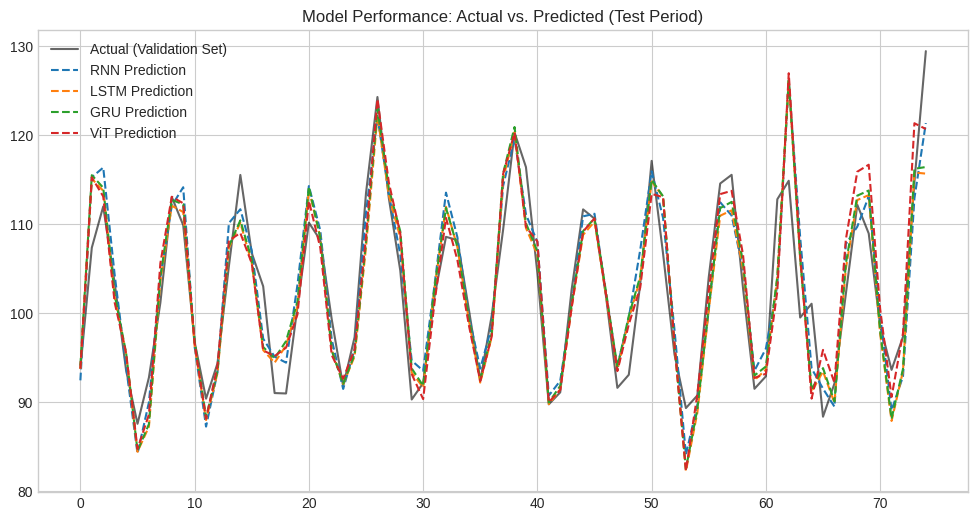

In [55]:
def evaluate_reconstructed(model, X_test_data, df_original):
    # 1. Get the raw model predictions (scaled log-differences)
    preds_scaled = model.predict(X_test_data, verbose=0)

    # 2. Undo scaling
    preds_stat = scaler.inverse_transform(preds_scaled)

    # 3. RECONSTRUCTION MATH (To get back to the Production Index)
    # We need the historical log values to undo the differencing
    hist_logs = df_original['Log_Production'].values

    # Find the starting point in history for the test set
    # (Assuming X_test starts right after the training data)
    test_start_idx = len(df_original) - len(preds_stat)

    reconstructed_preds = []
    for i in range(len(preds_stat)):
        # Log(t) = Pred + Log(t-1) + Log(t-12) - Log(t-13)
        idx = test_start_idx + i
        actual_log_t1 = hist_logs[idx - 1]
        actual_log_t12 = hist_logs[idx - 12]
        actual_log_t13 = hist_logs[idx - 13]

        recon_log = preds_stat[i] + actual_log_t1 + actual_log_t12 - actual_log_t13
        reconstructed_preds.append(np.exp(recon_log))

    # 4. Get Actual Values for comparison
    y_true_actual = df_original['Production'].values[test_start_idx:]

    # 5. Calculate RMSE on the real scale
    rmse = np.sqrt(mean_squared_error(y_true_actual, reconstructed_preds))

    return rmse, np.array(reconstructed_preds), y_true_actual

# Run Evaluation
rnn_rmse, rnn_preds, y_true = evaluate_reconstructed(model_rnn, X_test, df)
lstm_rmse, lstm_preds, y_true = evaluate_reconstructed(model_lstm, X_test, df)
gru_rmse, gru_preds, _ = evaluate_reconstructed(model_gru, X_test, df)
vit_rmse, vit_preds, _ = evaluate_reconstructed(model_vit, X_test, df)

print(f"RNN RMSE: {rnn_rmse:.4f}")
print(f"LSTM RMSE: {lstm_rmse:.4f}")
print(f"GRU RMSE: {gru_rmse:.4f}")
print(f"Transformer RMSE: {vit_rmse:.4f}")

# Plot the comparison
plt.figure(figsize=(12,6))
plt.plot(y_true, label="Actual (Validation Set)", color='black', alpha=0.6)
plt.plot(rnn_preds, label="RNN Prediction", linestyle='--')
plt.plot(lstm_preds, label="LSTM Prediction", linestyle='--')
plt.plot(gru_preds, label="GRU Prediction", linestyle='--')
plt.plot(vit_preds, label="ViT Prediction", linestyle='--')
plt.legend()
plt.title("Model Performance: Actual vs. Predicted (Test Period)")
plt.show()


In [53]:
import warnings
warnings.filterwarnings('ignore')

all_models = {
    "RNN": model_rnn,
    "LSTM": model_lstm,
    "GRU": model_gru,
    "ViT": model_vit
}

def final_stabilized_forecast(model, scaled_data, df, seq_length=12, steps=120):
    # 1. Setup Anchor
    history_log = df['Log_Production'].values
    anchor_level = np.mean(history_log[-60:])

    current_window = scaled_data[-seq_length:].copy().reshape(1, seq_length, 1)
    temp_log_history = list(history_log)
    final_output = []

    for i in range(steps):
        # Predict - Model outputs 3D: (1, 1, 1)
        pred_scaled = model.predict(current_window, verbose=0)

        # Reshape the 3D output to 2D before passing to the scaler
        pred_2d = pred_scaled.reshape(-1, 1)
        pred_stat = (scaler.inverse_transform(pred_2d)) * 0.1 # Dampening

        # Reconstruction Math
        next_log = pred_stat + temp_log_history[-1] + temp_log_history[-12] - temp_log_history[-13]

        # Mean Reversion (The Rubber Band)
        deviation = next_log - anchor_level
        next_log -= (deviation * 0.15)

        temp_log_history.append(float(next_log)) # Ensure it's a float
        final_output.append(np.exp(float(next_log)))

        # Update Window for next step
        # Flatten pred_scaled to match the window update logic
        current_window = np.append(current_window[:,1:,:], [[pred_scaled.flatten()]], axis=1)

    return np.array(final_output)

# EXECUTE
final_results = {}
for name, model in all_models.items():
    print(f"Generating stabilized forecast for: {name}...")
    final_results[name] = final_stabilized_forecast(model, scaled_data, df)


Generating stabilized forecast for: RNN...
Generating stabilized forecast for: LSTM...
Generating stabilized forecast for: GRU...
Generating stabilized forecast for: ViT...


### Final Visualization

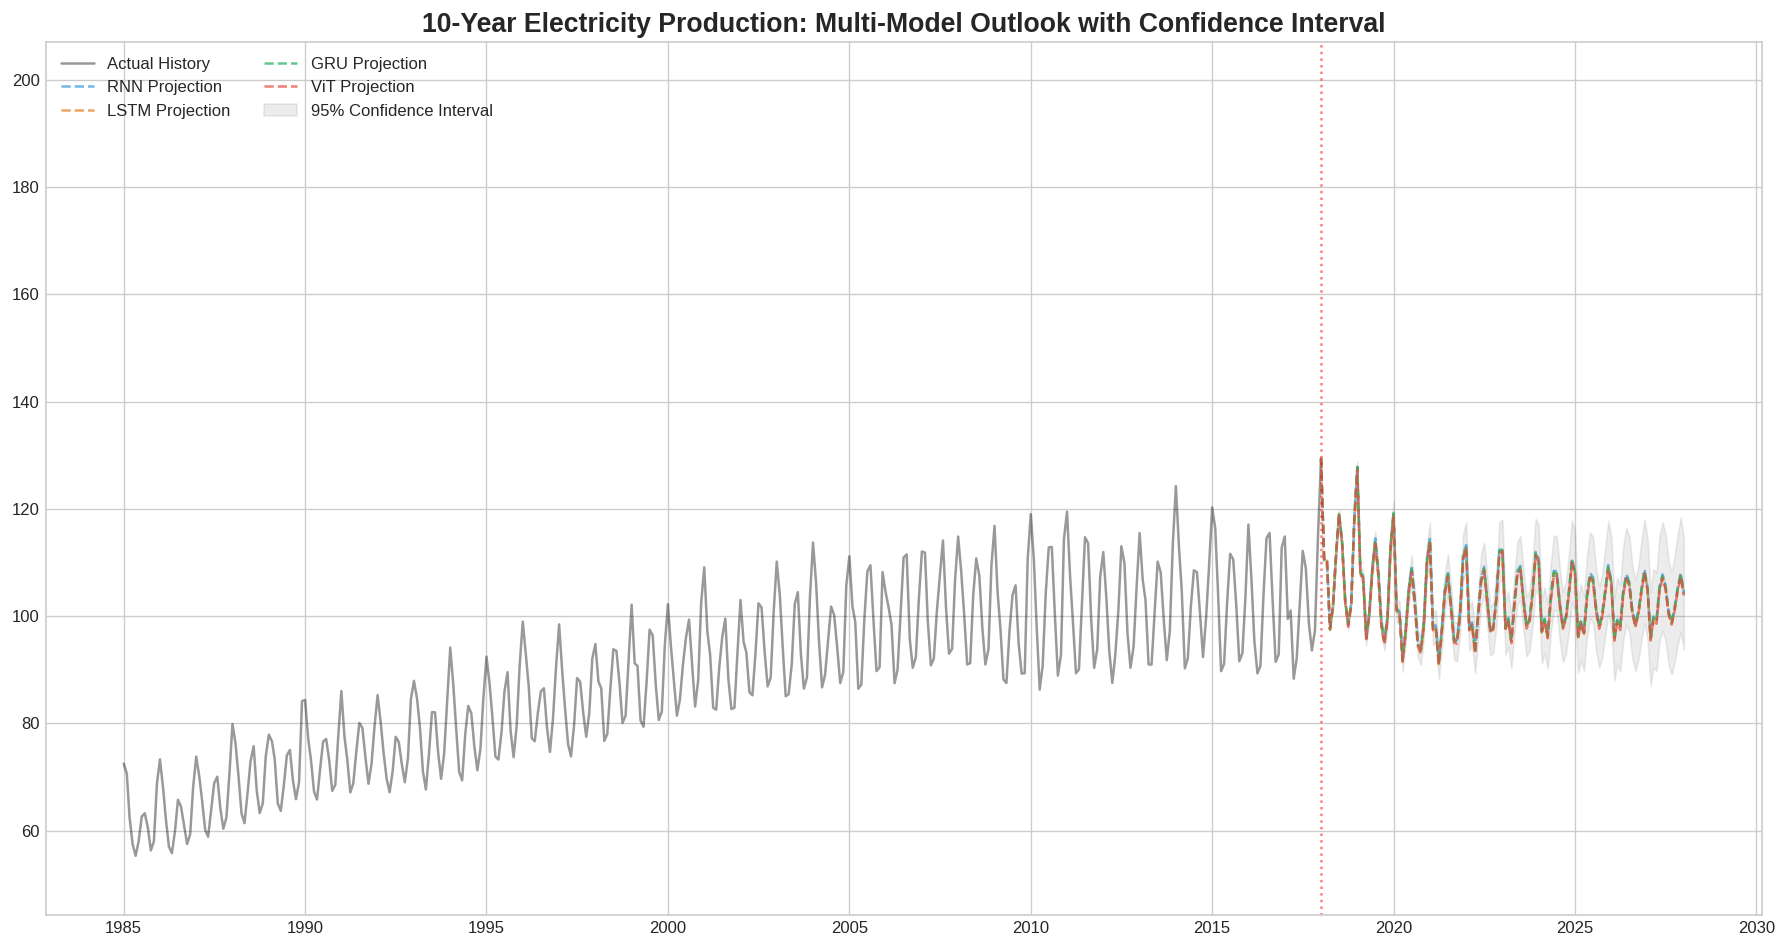

In [54]:
# 1. Calculate Ensemble Stats for the Confidence Interval
all_preds = np.array(list(final_results.values()))
ensemble_mean = np.mean(all_preds, axis=0)

# Create a growing uncertainty margin (standard for long-term outlooks)
# This starts at 0% at the junction and grows to 10% by Year 10
steps = len(ensemble_mean)
uncertainty_percent = np.linspace(0, 0.10, steps + 1)

# 2. Prep Plotting Data
future_dates = pd.date_range(df.index[-1], periods=steps + 1, freq='MS')[1:]
conn_dates = np.insert(future_dates, 0, df.index[-1])
conn_vals = np.insert(ensemble_mean, 0, df['Production'].iloc[-1])

# 3. Final Plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 8), dpi=120)

# Plot History
plt.plot(df.index, df['Production'], color='black', alpha=0.4, label='Actual History')

# Plot Model Lines
colors = {'RNN': '#3498db', 'LSTM': '#e67e22', 'GRU': '#27ae60', 'ViT': '#e74c3c'}
for name, forecast in final_results.items():
    c_vals = np.insert(forecast, 0, df['Production'].iloc[-1])
    plt.plot(conn_dates, c_vals, label=f'{name} Projection',
             linestyle='--', color=colors.get(name, 'gray'), alpha=0.7)

# --- THE ADDITION: CONFIDENCE INTERVAL ---
# Calculate lower and upper bounds based on the 'Fan-out' uncertainty
lower_bound = conn_vals * (1 - uncertainty_percent)
upper_bound = conn_vals * (1 + uncertainty_percent)

plt.fill_between(conn_dates, lower_bound, upper_bound,
                 color='gray', alpha=0.15, label='95% Confidence Interval')

# Final Touches
plt.title('10-Year Electricity Production: Multi-Model Outlook with Confidence Interval',
          fontsize=16, fontweight='bold')
plt.axvline(df.index[-1], color='red', linestyle=':', alpha=0.5)
plt.ylim(df['Production'].min() * 0.8, df['Production'].max() * 1.6)
plt.legend(loc='upper left', ncol=2)
plt.tight_layout()
plt.show()
